# Analyse XAI par dimension — modèle small2 (MegaDNA + NT2)

Ce notebook approfondit les Integrated Gradients (IG) au niveau de chaque dimension d'embedding,
pour le modèle `best_small2` (MegaDNA bactérie + NT2 phage, TruncateStrategy).

In [1]:
%cd ../..
!pwd

/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code
/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code


/home/nathan/anaconda3/envs/pbi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from captum.attr import IntegratedGradients

from pbi_utils.data_manager import H5pyEmbeddingsManager, PerphectDataInput
from main import parse_config, reduce_dimensionality, test_model, make_dataset

## 1. Chargement du modèle

In [3]:
config = parse_config(config_path="output/pbip/small2/training_config.yaml")

# Test dataset
config.input_perphect.couples_df = "data/perphect-data/predphi/predphi_test_dataset.csv"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

[INFO] Configuration loaded from output/pbip/small2/training_config.yaml: Config(input_perphect=bacteria_df='data/perphect-data/predphi/bacteria_sequences.csv' phages_df='data/perphect-data/predphi/bacteriophages_sequences.csv' couples_df='data/perphect-data/predphi/predphi_train_dataset.csv', embeddings_dir=data/embeddings-pbip, num_gpu=1, gpu_id=0, training_config=TrainingConfig(do_train=True do_test=False epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 training_noise_std=0.05 stratify_cv=True k_folds_cv=1 patience_early_stopping=1000 monitor_metric_early_stopping='f1' patience_reduce_lr=1000 monitor_metric_reduce_lr='f1' multiplying_factor_reduce_lr=0.5 reduce_dimensionality='none' n_components_bacteria=None n_components_phages=None), phages_embedding_models=[NT2(merging_strategy=TruncateStrategy(), overlap=0, model_name='nucleotide-transformer-v2-250m-multi-species')], compute_phages_embeddings=[True], bacteria_embedding_models=[MegaDNA(merging_strategy=TruncateSt

In [4]:
output_manager = H5pyEmbeddingsManager(config.embeddings_dir)
bacteria_df, phages_df, couples_df = PerphectDataInput(input_paths=config.input_perphect).load()

bacteria_model_names = [x.name() for x in config.bacteria_embedding_models]
phages_model_names   = [x.name() for x in config.phages_embedding_models]

dataset = make_dataset(couples_df, bacteria_model_names, phages_model_names, output_manager, device)
dataset = reduce_dimensionality(
    dataset,
    config.training_config.reduce_dimensionality,
    config.output_dir,
    config.training_config.n_components_bacteria,
    config.training_config.n_components_phages,
)
print(f"Dataset : {len(dataset)} samples")
dataset.head(2)

[INFO] Embeddings will be stored or read from data/embeddings-pbip
[INFO] Perphect input files will be read from data/perphect-data/predphi/bacteria_sequences.csv, data/perphect-data/predphi/bacteriophages_sequences.csv and data/perphect-data/predphi/predphi_test_dataset.csv
[INFO] Reading csv files...
[INFO] Creating dataset (loading embeddings)...
[DEBUG] Loading 1236 embeddings for model MegaDNA-TruncateStrategy-concat-ov0 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/1236 [00:00<?, ?it/s]

[DEBUG] Loading 1236 embeddings for model NT2-TruncateStrategy-250M-ov0 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/1236 [00:00<?, ?it/s]

[DEBUG] Final embedding size (bacteria): 964
[DEBUG] Final embedding size (phages): 768
Dataset : 1236 samples


,phage_id,bacterium_id,interaction_type,bacterium_embedding,phage_embedding
0,NC_019400,CALF01000071,1,"[tensor(0.1048, device='cuda:0'), tensor(0.033...","[tensor(0.1758, device='cuda:0'), tensor(0.233..."
1,MF919516,CP012196,0,"[tensor(-0.0355, device='cuda:0'), tensor(0.00...","[tensor(0.3073, device='cuda:0'), tensor(0.416..."


In [5]:
model_path = os.path.join(config.output_dir, "trained_model.pth")

bact_emb_size  = len(dataset["bacterium_embedding"].iloc[0])
phage_emb_size = len(dataset["phage_embedding"].iloc[0])
print(f"Taille embedding bactérie : {bact_emb_size}")
print(f"Taille embedding phage    : {phage_emb_size}")

model = config.classifier(bact_emb_size, phage_emb_size, **config.classifier_params)
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()
print("Modèle chargé.")

Taille embedding bactérie : 964
Taille embedding phage    : 768
Modèle chargé.


In [6]:
test_model(dataset, model, batch_size=config.training_config.batch_size, device=device);

def get_mcc(ds):
    cm, _ = test_model(ds, model, batch_size=config.training_config.batch_size, device=device, silent=True)
    tn, fp, fn, tp = cm.ravel()
    denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)) ** 0.5
    return (tp*tn - fp*fn) / denom if denom > 0 else 0.0


print(get_mcc(dataset))

[INFO] Starting testing...
[INFO] Accuracy (test): 0.7847896218299866
[INFO] Recall (test): 0.7766990065574646
[INFO] F1 score (test): 0.7830342650413513
[INFO] Loss (test): 0.5952161195594516
[INFO] Confusion Matrix (test) (TP, FP, FN, TN): (480, 128, 138, 490)
0.5696538697703055


## 2. Prédictions + baseline (médiane)

In [7]:
model.eval()
preds, probs = [], []
with torch.no_grad():
    for _, row in dataset.iterrows():
        out = model(
            row["bacterium_embedding"].unsqueeze(0).to(device),
            row["phage_embedding"].unsqueeze(0).to(device),
        )
        p = torch.softmax(out, dim=1)[0]
        preds.append(int(p.argmax().item()))
        probs.append(float(p[1].item()))

dataset["prediction"]  = preds
dataset["probability"] = probs

# Catégorie TP/TN/FP/FN
def outcome(row):
    t, p = int(row["interaction_type"]), int(row["prediction"])
    return {(1,1):"TP", (0,0):"TN", (0,1):"FP", (1,0):"FN"}[(t, p)]

dataset["outcome"] = dataset.apply(outcome, axis=1)
print(dataset["outcome"].value_counts())

outcome
TN    490
TP    480
FN    138
FP    128
Name: count, dtype: int64


In [8]:
all_bact_embs  = torch.stack([t.detach().cpu() for t in dataset["bacterium_embedding"]])
all_phage_embs = torch.stack([t.detach().cpu() for t in dataset["phage_embedding"]])

median_bact  = torch.median(all_bact_embs,  dim=0).values.float().to(device)
median_phage = torch.median(all_phage_embs, dim=0).values.float().to(device)

del all_bact_embs, all_phage_embs
print("Baseline médiane calculée.")

Baseline médiane calculée.


## 3. Calcul des IG par sample

In [9]:
def forward_prob(bact_emb, phage_emb):
    """Retourne prob(classe 1), shape [B, 1]."""
    return torch.sigmoid(model(bact_emb, phage_emb)[:, 1:2])

ig = IntegratedGradients(forward_prob)

# Vérification completeness sur 1 sample
row0 = dataset.iloc[0]
b0 = row0["bacterium_embedding"].to(device).unsqueeze(0)
p0 = row0["phage_embedding"].to(device).unsqueeze(0)

attr_b0, attr_p0 = ig.attribute(
    inputs=(b0, p0),
    baselines=(median_bact.unsqueeze(0), median_phage.unsqueeze(0)),
    target=0, n_steps=50,
)
with torch.no_grad():
    prob_x    = forward_prob(b0, p0).item()
    prob_base = forward_prob(median_bact.unsqueeze(0), median_phage.unsqueeze(0)).item()

ig_sum = attr_b0.sum().item() + attr_p0.sum().item()
delta  = prob_x - prob_base
print(f"Sum(IG)            : {ig_sum:.4f}")
print(f"prob(x)-prob(base) : {delta:.4f}")
print(f"Erreur completeness: {abs(ig_sum - delta):.6f}  (doit être proche de 0)")

Sum(IG)            : 0.2119
prob(x)-prob(base) : 0.2127
Erreur completeness: 0.000859  (doit être proche de 0)


In [10]:
N_STEPS = 50

ig_bact_raw  = np.zeros((len(dataset), bact_emb_size),  dtype=np.float32)
ig_phage_raw = np.zeros((len(dataset), phage_emb_size), dtype=np.float32)

model.eval()
for i, (_, row) in enumerate(tqdm(dataset.iterrows(), total=len(dataset), desc="IG")):
    b = row["bacterium_embedding"].clone().float().to(device).unsqueeze(0)
    p = row["phage_embedding"].clone().float().to(device).unsqueeze(0)
    attr_b, attr_p = ig.attribute(
        inputs=(b, p),
        baselines=(median_bact.unsqueeze(0), median_phage.unsqueeze(0)),
        target=0, n_steps=N_STEPS,
    )
    ig_bact_raw[i]  = attr_b.squeeze().cpu().numpy()
    ig_phage_raw[i] = attr_p.squeeze().cpu().numpy()

ig_bact_abs  = np.abs(ig_bact_raw)
ig_phage_abs = np.abs(ig_phage_raw)

mean_ig_bact  = ig_bact_abs.mean(axis=0)   # (D_bact,)
mean_ig_phage = ig_phage_abs.mean(axis=0)  # (D_phage,)

print(f"ig_bact_raw  : {ig_bact_raw.shape}")
print(f"ig_phage_raw : {ig_phage_raw.shape}")

IG: 100%|██████████| 1236/1236 [00:03<00:00, 314.45it/s]

ig_bact_raw  : (1236, 964)
ig_phage_raw : (1236, 768)


## 4. Top-k dimensions importantes

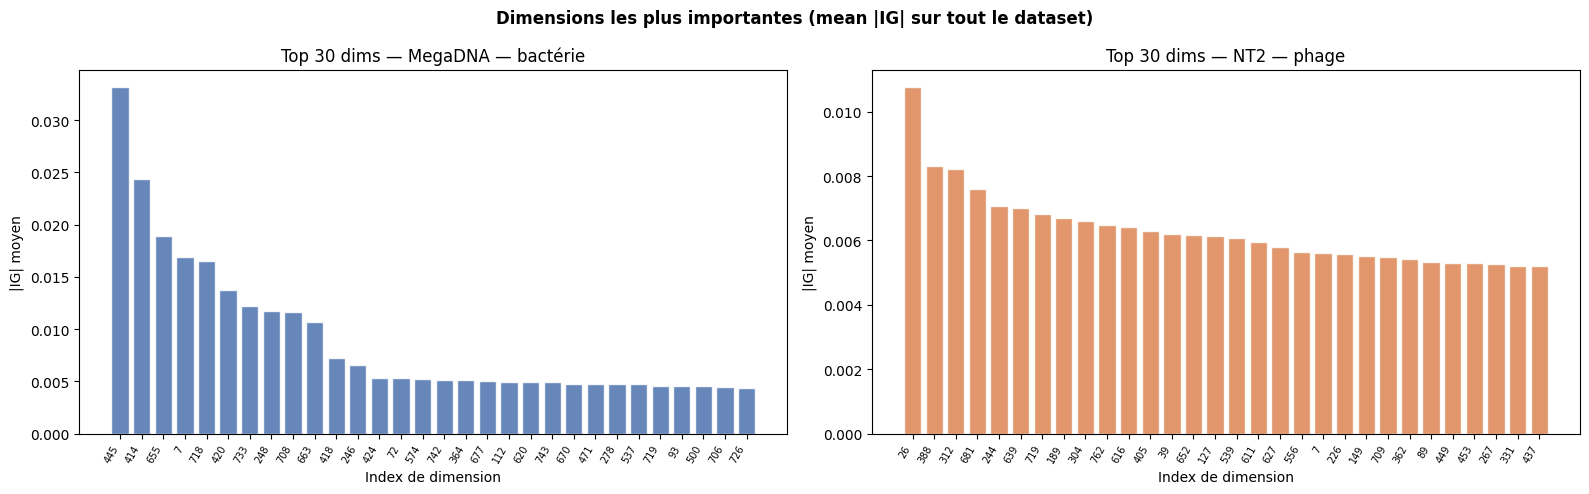

In [11]:
K = 30

top_bact_dims  = np.argsort(mean_ig_bact)[::-1][:K]
top_phage_dims = np.argsort(mean_ig_phage)[::-1][:K]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, dims, vals, title, color in [
    (axes[0], top_bact_dims,  mean_ig_bact[top_bact_dims],   "MegaDNA — bactérie", "#4C72B0"),
    (axes[1], top_phage_dims, mean_ig_phage[top_phage_dims], "NT2 — phage",        "#DD8452"),
]:
    ax.bar(range(K), vals, color=color, alpha=0.85, edgecolor="white")
    ax.set_xticks(range(K))
    ax.set_xticklabels([str(d) for d in dims], rotation=60, ha="right", fontsize=7)
    ax.set_xlabel("Index de dimension")
    ax.set_ylabel("|IG| moyen")
    ax.set_title(f"Top {K} dims — {title}")

plt.suptitle("Dimensions les plus importantes (mean |IG| sur tout le dataset)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Distribution IG par dimension (boxplot)

Montre si l'importance est stable sur tous les samples ou très variable.

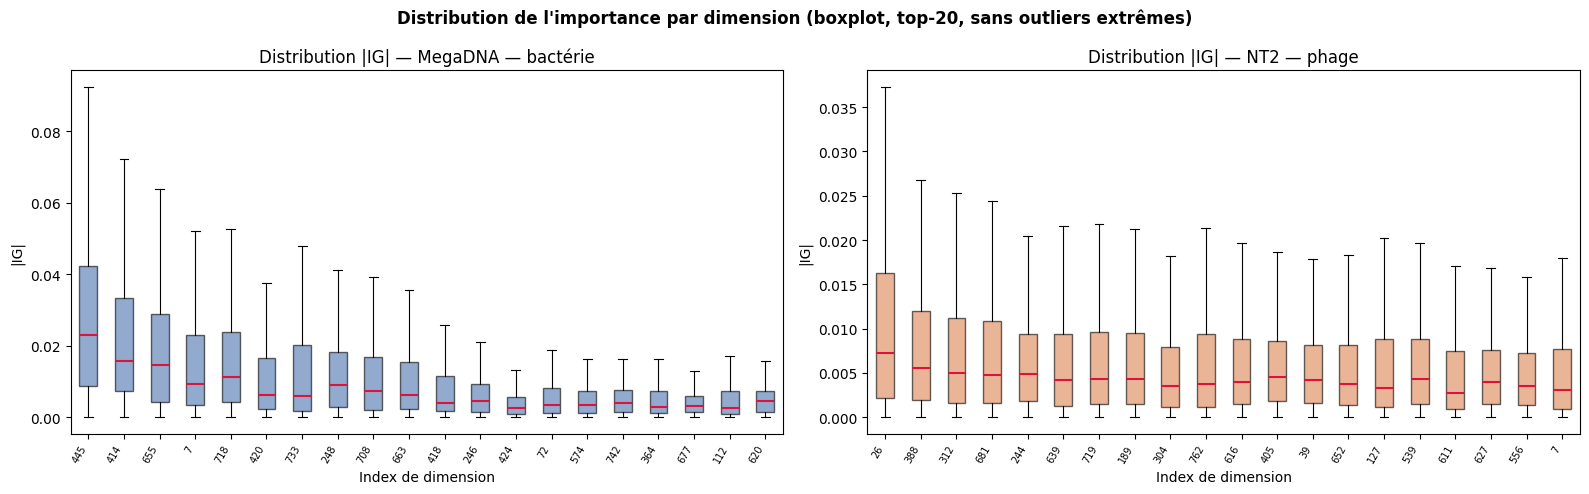

In [12]:
K_BOX = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, dims, ig_abs, title, color in [
    (axes[0], top_bact_dims[:K_BOX],  ig_bact_abs[:, top_bact_dims[:K_BOX]],   "MegaDNA — bactérie", "#4C72B0"),
    (axes[1], top_phage_dims[:K_BOX], ig_phage_abs[:, top_phage_dims[:K_BOX]], "NT2 — phage",        "#DD8452"),
]:
    ax.boxplot(
        [ig_abs[:, i] for i in range(K_BOX)],
        positions=range(K_BOX),
        showfliers=False,
        patch_artist=True,
        medianprops=dict(color="crimson", linewidth=1.5),
        boxprops=dict(facecolor=color, alpha=0.6),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
    )
    ax.set_xticks(range(K_BOX))
    ax.set_xticklabels([str(d) for d in dims[:K_BOX]], rotation=60, ha="right", fontsize=7)
    ax.set_xlabel("Index de dimension")
    ax.set_ylabel("|IG|")
    ax.set_title(f"Distribution |IG| — {title}")

plt.suptitle("Distribution de l'importance par dimension (boxplot, top-20, sans outliers extrêmes)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Sélection de dimensions guidée par IG + réentraînement

In [13]:
import copy
from main import train_nn_model

# Réutilise la même config que pour le test set, sinon on risque un mismatch
# entre les dims attendues par `model` et celles produites par le dataset.
config_tr = copy.deepcopy(config)
config_tr.input_perphect.couples_df = "data/perphect-data/predphi/predphi_train_dataset.csv"

output_manager_tr = H5pyEmbeddingsManager(config_tr.embeddings_dir)
_, _, couples_df_tr = PerphectDataInput(input_paths=config_tr.input_perphect).load()

bact_names  = [x.name() for x in config_tr.bacteria_embedding_models]
phage_names = [x.name() for x in config_tr.phages_embedding_models]

dataset_train = make_dataset(couples_df_tr, bact_names, phage_names, output_manager_tr, device)
dataset_train = reduce_dimensionality(
    dataset_train,
    config_tr.training_config.reduce_dimensionality,
    config_tr.output_dir,
    config_tr.training_config.n_components_bacteria,
    config_tr.training_config.n_components_phages,
)
print(f"Train set : {len(dataset_train)} samples")
print(f"bact_size={len(dataset_train['bacterium_embedding'].iloc[0])}  "
      f"phage_size={len(dataset_train['phage_embedding'].iloc[0])}")


[INFO] Embeddings will be stored or read from data/embeddings-pbip
[INFO] Perphect input files will be read from data/perphect-data/predphi/bacteria_sequences.csv, data/perphect-data/predphi/bacteriophages_sequences.csv and data/perphect-data/predphi/predphi_train_dataset.csv
[INFO] Reading csv files...
[INFO] Creating dataset (loading embeddings)...
[DEBUG] Loading 5702 embeddings for model MegaDNA-TruncateStrategy-concat-ov0 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/5702 [00:00<?, ?it/s]

[DEBUG] Loading 5702 embeddings for model NT2-TruncateStrategy-250M-ov0 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/5702 [00:00<?, ?it/s]

[DEBUG] Final embedding size (bacteria): 964
[DEBUG] Final embedding size (phages): 768
Train set : 5702 samples
bact_size=964  phage_size=768


In [14]:
# IG sur le train set (pour éviter le data leakage dans la sélection de dims)
all_bact_tr  = torch.stack([t.detach().cpu() for t in dataset_train["bacterium_embedding"]])
all_phage_tr = torch.stack([t.detach().cpu() for t in dataset_train["phage_embedding"]])
median_bact_tr  = torch.median(all_bact_tr,  dim=0).values.float().to(device)
median_phage_tr = torch.median(all_phage_tr, dim=0).values.float().to(device)
del all_bact_tr, all_phage_tr

ig_bact_tr  = np.zeros((len(dataset_train), bact_emb_size),  dtype=np.float32)
ig_phage_tr = np.zeros((len(dataset_train), phage_emb_size), dtype=np.float32)

model.eval()
for i, (_, row) in enumerate(tqdm(dataset_train.iterrows(), total=len(dataset_train), desc="IG train")):
    b = row["bacterium_embedding"].clone().float().to(device).unsqueeze(0)
    p = row["phage_embedding"].clone().float().to(device).unsqueeze(0)
    ab, ap = ig.attribute(
        inputs=(b, p),
        baselines=(median_bact_tr.unsqueeze(0), median_phage_tr.unsqueeze(0)),
        target=0, n_steps=N_STEPS,
    )
    ig_bact_tr[i]  = ab.squeeze().cpu().numpy()
    ig_phage_tr[i] = ap.squeeze().cpu().numpy()

mean_ig_bact_tr  = np.abs(ig_bact_tr).mean(axis=0)
mean_ig_phage_tr = np.abs(ig_phage_tr).mean(axis=0)
print("IG train calculés.")

IG train: 100%|██████████| 5702/5702 [00:18<00:00, 313.11it/s]

IG train calculés.


MegaDNA (bact) : 69 dims (7.2%) capturent 30% de l'IG  |  402 (41.7%) pour 80%  |  639 (66.3%) pour 95%
NT2 (phage) : 125 dims (16.3%) capturent 30% de l'IG  |  503 (65.5%) pour 80%  |  682 (88.8%) pour 95%


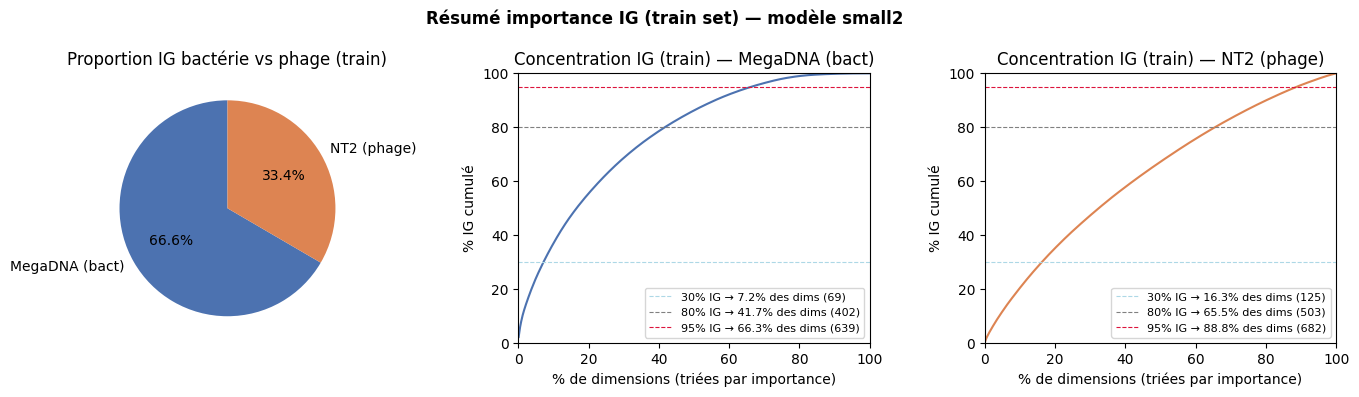

In [15]:
# Résumé d'importance IG — on utilise ici l'IG calculé sur le train set
# (mean_ig_bact_tr / mean_ig_phage_tr) pour cohérence avec la sélection
# effective des dims plus bas dans le notebook.

total_bact  = mean_ig_bact_tr.sum()
total_phage = mean_ig_phage_tr.sum()
total       = total_bact + total_phage

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

def dims_for_threshold(mean_ig, pct):
    """Retourne les indices des dims qui capturent `pct`% de l'IG cumulé."""
    if pct >= 100:
        return np.arange(len(mean_ig))
    order  = np.argsort(mean_ig)[::-1]
    cumsum = np.cumsum(mean_ig[order]) / mean_ig.sum()
    k = int(np.searchsorted(cumsum, pct / 100.0)) + 1
    return np.sort(order[:k])

# Pie bact vs phage
axes[0].pie(
    [total_bact, total_phage],
    labels=["MegaDNA (bact)", "NT2 (phage)"],
    colors=["#4C72B0", "#DD8452"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[0].set_title("Proportion IG bactérie vs phage (train)")

# Concentration : courbe d'IG cumulé + repères 30/80/95 %
for ax, mean_ig, title, color in [
    (axes[1], mean_ig_bact_tr,  "MegaDNA (bact)", "#4C72B0"),
    (axes[2], mean_ig_phage_tr, "NT2 (phage)",    "#DD8452"),
]:
    n_dims    = len(mean_ig)
    sorted_ig = np.sort(mean_ig)[::-1]
    cumsum    = np.cumsum(sorted_ig) / sorted_ig.sum()
    pct_dims  = np.arange(1, n_dims + 1) / n_dims * 100
    k30 = len(dims_for_threshold(mean_ig, 30))
    k80 = len(dims_for_threshold(mean_ig, 80))
    k95 = len(dims_for_threshold(mean_ig, 95))
    ax.plot(pct_dims, cumsum * 100, color=color, linewidth=1.5)
    ax.axhline(30, color="lightblue", linestyle="--", lw=0.8,
               label=f"30% IG → {100*k30/n_dims:.1f}% des dims ({k30})")
    ax.axhline(80, color="grey", linestyle="--", lw=0.8,
               label=f"80% IG → {100*k80/n_dims:.1f}% des dims ({k80})")
    ax.axhline(95, color="crimson", linestyle="--", lw=0.8,
               label=f"95% IG → {100*k95/n_dims:.1f}% des dims ({k95})")
    ax.set_xlabel("% de dimensions (triées par importance)")
    ax.set_ylabel("% IG cumulé")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_title(f"Concentration IG (train) — {title}")
    ax.legend(fontsize=8, loc="lower right")
    print(f"{title} : {k30} dims ({100*k30/n_dims:.1f}%) capturent 30% de l'IG  |  "
          f"{k80} ({100*k80/n_dims:.1f}%) pour 80%  |  {k95} ({100*k95/n_dims:.1f}%) pour 95%")

plt.suptitle("Résumé importance IG (train set) — modèle small2", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import matthews_corrcoef

def dims_for_threshold(mean_ig, pct):
    """Retourne les indices des dims qui capturent `pct`% de l'IG cumulé."""
    if pct >= 100:
        return np.arange(len(mean_ig))
    order  = np.argsort(mean_ig)[::-1]
    cumsum = np.cumsum(mean_ig[order]) / mean_ig.sum()
    k = int(np.searchsorted(cumsum, pct / 100.0)) + 1
    return np.sort(order[:k])

def select_dims_in_dataset(ds, bact_dims, phage_dims):
    """Retourne un dataset avec uniquement les dims sélectionnées."""
    ds2 = ds.copy()
    ds2["bacterium_embedding"] = [e[bact_dims].float()  for e in ds["bacterium_embedding"]]
    ds2["phage_embedding"]     = [e[phage_dims].float() for e in ds["phage_embedding"]]
    return ds2

def get_mcc_new_model(ds_tr, ds_te, bact_dims, phage_dims):
    """Réentraîne un modèle sur les dims sélectionnées et retourne le MCC sur le test set."""
    ds_tr_sel = select_dims_in_dataset(ds_tr, bact_dims, phage_dims)
    ds_te_sel = select_dims_in_dataset(ds_te, bact_dims, phage_dims)

    new_model = config.classifier(
        len(bact_dims), len(phage_dims), **config.classifier_params
    ).to(device)

    train_nn_model(
        ds_tr_sel, new_model, config.training_config,
        device=device, verbose=0,
    )

    new_model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for _, row in ds_te_sel.iterrows():
            out = new_model(
                row["bacterium_embedding"].unsqueeze(0).to(device),
                row["phage_embedding"].unsqueeze(0).to(device),
            )
            preds.append(int(out.argmax(dim=1).item()))
            labels.append(int(row["interaction_type"]))

    return matthews_corrcoef(labels, preds)

### 10a. Balayage des seuils X % d'IG cumulé

Pour chaque seuil X ∈ {5, 10, 20, …, 100} %, on sélectionne les dims qui
capturent X % de l'IG cumulé et on réentraîne `N_RUNS` fois un classifieur
dessus. On reporte le MCC moyen ± std pour chaque seuil.

In [17]:
IG_THRESHOLDS   = [5, 10, 20, 30, 40, 50, 65, 80, 100]
N_RUNS          = 10

# --- Charge le dataset `all` (généralisation) une seule fois ---
config_all = copy.deepcopy(config_tr)
config_all.input_perphect.couples_df  = "data/perphect-data/all/couples_df.csv"
config_all.input_perphect.bacteria_df = "data/perphect-data/all/bacteria_df.csv"
config_all.input_perphect.phages_df   = "data/perphect-data/all/phages_df.csv"
output_manager_all = H5pyEmbeddingsManager("data/embeddings")
_, _, couples_all = PerphectDataInput(input_paths=config_all.input_perphect).load()
dataset_all = make_dataset(couples_all, bact_names, phage_names, output_manager_all, device)
dataset_all = reduce_dimensionality(
    dataset_all,
    config_all.training_config.reduce_dimensionality, config_all.output_dir,
    config_all.training_config.n_components_bacteria,
    config_all.training_config.n_components_phages,
)
print(f"Dataset `all` chargé : {len(dataset_all)} samples")


def train_and_eval(ds_tr, eval_sets, bact_dims, phage_dims):
    """Entraîne 1 modèle frais sur ds_tr (slicé) et évalue sur chaque dataset
    de eval_sets. Retourne {name: mcc}."""
    ds_tr_sel = select_dims_in_dataset(ds_tr, bact_dims, phage_dims)
    new_model = config.classifier(
        len(bact_dims), len(phage_dims), **config.classifier_params
    ).to(device)
    train_nn_model(ds_tr_sel, new_model, config.training_config, device=device, verbose=0)
    new_model.eval()
    mccs = {}
    for name, ds in eval_sets.items():
        ds_sel = select_dims_in_dataset(ds, bact_dims, phage_dims)
        preds, labels = [], []
        with torch.no_grad():
            for _, row in ds_sel.iterrows():
                out = new_model(
                    row["bacterium_embedding"].unsqueeze(0).to(device),
                    row["phage_embedding"].unsqueeze(0).to(device),
                )
                preds.append(int(out.argmax(dim=1).item()))
                labels.append(int(row["interaction_type"]))
        mccs[name] = matthews_corrcoef(labels, preds)
    return mccs

eval_sets = {"test": dataset, "all": dataset_all}

# ============================================================
#  Balayage des seuils de % d'IG cumulé
# ============================================================
print("=== Balayage IG ===")
records_ig = []
for pct in IG_THRESHOLDS:
    bact_dims  = dims_for_threshold(mean_ig_bact_tr,  pct)
    phage_dims = dims_for_threshold(mean_ig_phage_tr, pct)
    mccs_test, mccs_all = [], []
    for _ in range(N_RUNS):
        out = train_and_eval(dataset_train, eval_sets, bact_dims, phage_dims)
        mccs_test.append(out["test"])
        mccs_all.append(out["all"])
    records_ig.append({
        "pct_ig":         pct,
        "n_bact":         len(bact_dims),
        "n_phage":        len(phage_dims),
        "n_total":        len(bact_dims) + len(phage_dims),
        "mcc_test_mean":  float(np.mean(mccs_test)),
        "mcc_test_std":   float(np.std(mccs_test)),
        "mcc_all_mean":   float(np.mean(mccs_all)),
        "mcc_all_std":    float(np.std(mccs_all)),
    })
    print(f"  {pct:3d}% IG → {len(bact_dims)+len(phage_dims):4d} dims"
          f" | test {np.mean(mccs_test):.3f}±{np.std(mccs_test):.3f}"
          f" | all {np.mean(mccs_all):.3f}±{np.std(mccs_all):.3f}")

df_ig = pd.DataFrame(records_ig)

print("\n--- df_ig ---")
print(df_ig.to_string(index=False))


[INFO] Embeddings will be stored or read from data/embeddings
[INFO] Perphect input files will be read from data/perphect-data/all/bacteria_df.csv, data/perphect-data/all/phages_df.csv and data/perphect-data/all/couples_df.csv
[INFO] Reading csv files...
[INFO] Creating dataset (loading embeddings)...
[DEBUG] Loading 7720 embeddings for model MegaDNA-TruncateStrategy-concat-ov0 from data/embeddings


Loading embeddings:   0%|          | 0/7720 [00:00<?, ?it/s]

[DEBUG] Loading 7720 embeddings for model NT2-TruncateStrategy-250M-ov0 from data/embeddings


Loading embeddings:   0%|          | 0/7720 [00:00<?, ?it/s]

[DEBUG] Final embedding size (bacteria): 964
[DEBUG] Final embedding size (phages): 768
Dataset `all` chargé : 7720 samples
=== Balayage IG ===
    5% IG →   18 dims | test 0.429±0.016 | all 0.234±0.009
   10% IG →   44 dims | test 0.511±0.041 | all 0.240±0.013
   20% IG →  112 dims | test 0.529±0.024 | all 0.254±0.014
   30% IG →  194 dims | test 0.549±0.015 | all 0.287±0.023
   40% IG →  293 dims | test 0.568±0.016 | all 0.311±0.014
   50% IG →  409 dims | test 0.561±0.018 | all 0.300±0.019
   65% IG →  625 dims | test 0.555±0.020 | all 0.322±0.025
   80% IG →  905 dims | test 0.555±0.020 | all 0.324±0.023
  100% IG → 1732 dims | test 0.550±0.023 | all 0.318±0.018

--- df_ig ---
 pct_ig  n_bact  n_phage  n_total  mcc_test_mean  mcc_test_std  mcc_all_mean  mcc_all_std
      5       4       14       18       0.429093      0.015999      0.234405     0.008935
     10      12       32       44       0.511496      0.041491      0.240236     0.013383
     20      37       75      112       

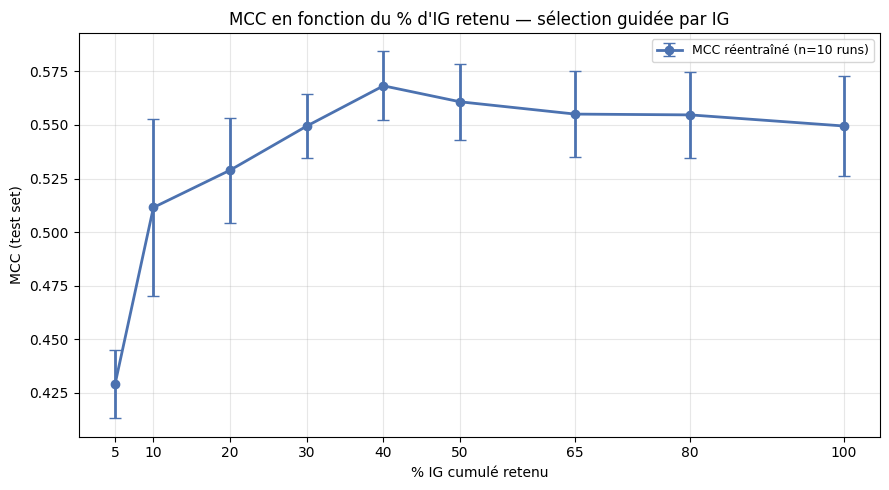

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(
    df_ig["pct_ig"], df_ig["mcc_test_mean"], yerr=df_ig["mcc_test_std"],
    fmt="o-", color="#4C72B0", linewidth=2, markersize=6, capsize=4,
    label=f"MCC réentraîné (n={N_RUNS} runs)",
)

ax.set_xticks(df_ig["pct_ig"])
ax.set_xlabel("% IG cumulé retenu")
ax.set_ylabel("MCC (test set)")
ax.set_title("MCC en fonction du % d'IG retenu — sélection guidée par IG")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 11. Réentraînement et sauvegarde du modèle 30% IG

In [19]:
if False:    
# Sélection des dimensions à 30% IG cumulé (calculées sur le train set)
    DIMS = 30


    bact_dims_30  = dims_for_threshold(mean_ig_bact_tr,  DIMS)
    phage_dims_30 = dims_for_threshold(mean_ig_phage_tr, DIMS)
    print(f"Bactérie : {len(bact_dims_30)}/{bact_emb_size} dims")
    print(f"Phage    : {len(phage_dims_30)}/{phage_emb_size} dims")

    # Réentraînement
    ds_tr_30 = select_dims_in_dataset(dataset_train, bact_dims_30, phage_dims_30)

    model_30 = config.classifier(
        len(bact_dims_30), len(phage_dims_30), **config.classifier_params
    ).to(device)

    train_nn_model(ds_tr_30, model_30, config.training_config, device=device, verbose=1)

    # Évaluation sur le test set
    ds_te_30 = select_dims_in_dataset(dataset, bact_dims_30, phage_dims_30)
    model_30.eval()
    preds_30, labels_30 = [], []
    with torch.no_grad():
        for _, row in ds_te_30.iterrows():
            out = model_30(
                row["bacterium_embedding"].unsqueeze(0).to(device),
                row["phage_embedding"].unsqueeze(0).to(device),
            )
            preds_30.append(int(out.argmax(dim=1).item()))
            labels_30.append(int(row["interaction_type"]))

    from sklearn.metrics import matthews_corrcoef
    mcc_30 = matthews_corrcoef(labels_30, preds_30)
    print(f"\nMCC modèle {DIMS}% IG : {mcc_30:.4f}")

    # Sauvegarde
    save_dir = os.path.join(config.output_dir, f"ig{DIMS}")
    os.makedirs(save_dir, exist_ok=True)

    torch.save(model_30.state_dict(), os.path.join(save_dir, "trained_model.pth"))
    np.save(os.path.join(save_dir, "bact_dims.npy"),  bact_dims_30)
    np.save(os.path.join(save_dir, "phage_dims.npy"), phage_dims_30)

    print(f"Modèle sauvegardé dans {save_dir}/")
    print(f"  trained_model.pth  — poids du modèle")
    print(f"  bact_dims.npy      — {len(bact_dims_30)} indices de dims bactérie")
    print(f"  phage_dims.npy     — {len(phage_dims_30)} indices de dims phage")
